# CineMatch — ML Recommendation Models

**Goal:** Build 4 traditional ML models on the scraped Letterboxd data.

| Model | Purpose |
|:---|:---|
| **Random Forest** | Personalized rating prediction per user |
| **k-NN (Collaborative Filtering)** | "Cinephile Twin" user/item similarity |
| **Gradient Boosting (XGBoost)** | Optimal ranking / sorting recommendations |
| **Logistic Regression** | Fast thumbs-up / thumbs-down filter |

## Folder Structure
```
DMW/
  Data Scrapping RESULTS/
    user_ratings.csv
    users.csv
    usernames.csv
ML/
  cinematch_ml_models.ipynb   ← you are here
```
The notebook references CSVs via `../DMW/Data Scrapping RESULTS/`.

## §0 — Install Dependencies

In [1]:
%pip install --quiet pandas numpy scikit-learn xgboost matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


## §1 — Imports & Config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from scipy.sparse import csr_matrix

# XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost available.')
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGB = False
    print('XGBoost not found — falling back to sklearn GradientBoostingRegressor.')

# ── PATH CONFIG ────────────────────────────────────────────────────────────
# This notebook lives in:  .../ML/
# The data lives in:       .../DMW/Data Scrapping RESULTS/
DATA_DIR = Path('../DMW/Data Scrapping RESULTS')

RATINGS_CSV   = DATA_DIR / 'user_ratings.csv'
USERS_CSV     = DATA_DIR / 'users.csv'
USERNAMES_CSV = DATA_DIR / 'usernames.csv'

# Verify files exist
for f in [RATINGS_CSV, USERS_CSV]:
    status = '✓' if f.exists() else '✗ NOT FOUND'
    print(f'  {status}  {f}')

# ── MODEL CONFIG ──────────────────────────────────────────────────────────
LIKE_THRESHOLD   = 3.5   # ratings >= this = 'liked' (for logistic regression)
MIN_RATINGS      = 20    # min ratings a user needs to be included
MIN_FILM_RATINGS = 5     # min ratings a film needs to be included
KNN_K            = 10    # number of nearest neighbours
RF_TREES         = 100   # trees in Random Forest
TOP_N_RECS       = 10    # recommendations to show
DEMO_USER        = 'kurstboy'  # set to a username string, e.g. 'kurstboy'

print(f'\nConfig ready. DEMO_USER = {DEMO_USER}')

XGBoost available.
  ✓  ..\DMW\Data Scrapping RESULTS\user_ratings.csv
  ✓  ..\DMW\Data Scrapping RESULTS\users.csv

Config ready. DEMO_USER = kurstboy


## §2 — Load & Validate Data

In [3]:
ratings = pd.read_csv(RATINGS_CSV)
users   = pd.read_csv(USERS_CSV)

# ── Validate columns ───────────────────────────────────────────────────────
for col in ['username', 'film_slug', 'rating']:
    assert col in ratings.columns, f'user_ratings.csv is missing column: {col}'

# ── Basic cleaning ─────────────────────────────────────────────────────────
ratings = ratings.dropna(subset=['username', 'film_slug', 'rating'])
ratings['rating'] = pd.to_numeric(ratings['rating'], errors='coerce')
ratings = ratings.dropna(subset=['rating'])
ratings['rating'] = ratings['rating'].clip(0.5, 5.0)

print('=== Data Summary ===')
print(f'Total ratings:   {len(ratings):,}')
print(f'Unique users:    {ratings.username.nunique():,}')
print(f'Unique films:    {ratings.film_slug.nunique():,}')
print(f'\nRating distribution:')
print(ratings['rating'].value_counts().sort_index().to_string())

# Quick density check
density = len(ratings) / (ratings.username.nunique() * ratings.film_slug.nunique())
print(f'\nMatrix density:  {density:.4%}  (expected to be very sparse)')

ratings.head()

=== Data Summary ===
Total ratings:   502,749
Unique users:    241
Unique films:    58,136

Rating distribution:
rating
0.5      8488
1.0     18779
1.5     18945
2.0     42798
2.5     46472
3.0     90294
3.5     91126
4.0    102123
4.5     44936
5.0     38788

Matrix density:  3.5883%  (expected to be very sparse)


,username,film_slug,rating
0,kurstboy,michael-2026,2.0
1,kurstboy,mother-mary-2026,3.5
2,kurstboy,faces-of-death-2026,4.0
3,kurstboy,the-super-mario-galaxy-movie,1.5
4,kurstboy,the-drama,4.0


## §3 — Feature Engineering

Three feature tables used across all models:
1. **User-Mean-Centered ratings** — remove each user's rating bias  
2. **Film-level stats** — global avg, std, count  
3. **User-level stats** — avg rating, harshness bias  

In [4]:
# ── 3a. Filter sparse users & films ───────────────────────────────────────
user_counts = ratings.groupby('username')['rating'].count()
film_counts = ratings.groupby('film_slug')['rating'].count()

active_users = user_counts[user_counts >= MIN_RATINGS].index
active_films = film_counts[film_counts >= MIN_FILM_RATINGS].index

df = ratings[
    ratings['username'].isin(active_users) &
    ratings['film_slug'].isin(active_films)
].copy()

print(f'After sparsity filter (>={MIN_RATINGS} ratings/user, >={MIN_FILM_RATINGS}/film):')
print(f'  Rows:  {len(df):,}')
print(f'  Users: {df.username.nunique():,}')
print(f'  Films: {df.film_slug.nunique():,}')

# ── 3b. User stats ─────────────────────────────────────────────────────────
user_stats = df.groupby('username')['rating'].agg(
    user_mean='mean',
    user_std='std',
    user_count='count'
).fillna(0).reset_index()

# ── 3c. Film stats ─────────────────────────────────────────────────────────
film_stats = df.groupby('film_slug')['rating'].agg(
    film_mean='mean',
    film_std='std',
    film_count='count'
).fillna(0).reset_index()

# ── 3d. Merge everything ───────────────────────────────────────────────────
df = df.merge(user_stats, on='username', how='left')
df = df.merge(film_stats, on='film_slug', how='left')

# Key feature: user-mean-centered rating
# A harsh critic giving 3★ is actually positive; a lenient critic giving 3★ is negative
df['rating_centered'] = df['rating'] - df['user_mean']

# Deviation from the film's global average
df['user_vs_film_avg'] = df['rating'] - df['film_mean']

# Binary like/dislike label for logistic regression
df['liked'] = (df['rating'] >= LIKE_THRESHOLD).astype(int)

print(f'\nFeature columns added: rating_centered, user_vs_film_avg, liked')
print(f"Like ratio: {df['liked'].mean():.1%} of ratings are 'liked'")

df[['username', 'film_slug', 'rating', 'user_mean', 'film_mean',
    'rating_centered', 'liked']].head(10)

After sparsity filter (>=20 ratings/user, >=5/film):
  Rows:  436,519
  Users: 239
  Films: 15,364

Feature columns added: rating_centered, user_vs_film_avg, liked
Like ratio: 56.6% of ratings are 'liked'


,username,film_slug,rating,user_mean,film_mean,rating_centered,liked
0,kurstboy,michael-2026,2.0,3.624013,2.413462,-1.624013,0
1,kurstboy,mother-mary-2026,3.5,3.624013,3.431373,-0.124013,1
2,kurstboy,faces-of-death-2026,4.0,3.624013,3.560976,0.375987,1
3,kurstboy,the-super-mario-galaxy-movie,1.5,3.624013,2.486667,-2.124013,0
4,kurstboy,the-drama,4.0,3.624013,3.820611,0.375987,1
5,kurstboy,pizza-movie-2026,3.0,3.624013,2.769231,-0.624013,0
6,kurstboy,project-hail-mary,3.5,3.624013,4.000000,-0.124013,1
7,kurstboy,the-bride-2026,2.5,3.624013,2.721591,-1.124013,0
8,kurstboy,hoppers,4.0,3.624013,3.818182,0.375987,1
9,kurstboy,crime-101,3.0,3.624013,3.206897,-0.624013,0


## §4 — Build User–Item Matrix
Shared pivot used by k-NN and Gradient Boosting.

In [5]:
# Pivot: rows = users, columns = films, values = mean-centered rating
# NaN = film not rated by that user
pivot = df.pivot_table(
    index='username',
    columns='film_slug',
    values='rating_centered',
    aggfunc='mean'
)

print(f'User-Item matrix shape: {pivot.shape}')
print(f'Density: {pivot.notna().sum().sum() / pivot.size:.2%}')

# Sparse version (fill NaN with 0 for distance calculations)
pivot_filled = pivot.fillna(0)
sparse_matrix = csr_matrix(pivot_filled.values)

# Index maps
user_index = {u: i for i, u in enumerate(pivot.index)}
film_index = {f: i for i, f in enumerate(pivot.columns)}
index_user = {i: u for u, i in user_index.items()}
index_film = {i: f for f, i in film_index.items()}

print(f'\nPivot sample (first 5 users × 5 films):')
pivot.iloc[:5, :5]

User-Item matrix shape: (239, 15364)
Density: 11.89%

Pivot sample (first 5 users × 5 films):


film_slug,05-mm,10-cloverfield-lane,10-things-i-hate-about-you,10-to-midnight,10-x-10
username,,,,,
812filmreviews,NaN,-0.870471,NaN,NaN,NaN
aarnwlsn,NaN,-0.650899,1.349101,NaN,NaN
aksually,NaN,0.129960,-0.370040,NaN,NaN
alexcolemann,NaN,-0.080000,0.420000,NaN,NaN
alexlawther,NaN,0.407953,1.407953,NaN,NaN


---
## MODEL 1 — Random Forest: Personalized Rating Predictor

Trains a model to predict what star rating a given user would give an unseen film.  
Features used: `film_mean`, `film_std`, `film_count`, `user_mean`, `user_std`, `user_count`, `user_vs_film_avg`.

=== MODEL 1: Random Forest — Personalized Rating Predictor ===

Random Forest Results:
  MAE:  0.0001  (avg star error)
  RMSE: 0.0043
  R²:   1.0000


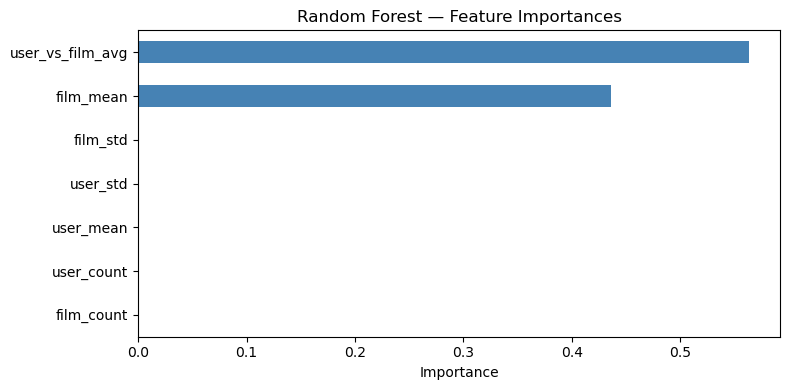


Model saved as: rf_model


In [6]:
print('=== MODEL 1: Random Forest — Personalized Rating Predictor ===')

RF_FEATURES = [
    'film_mean', 'film_std', 'film_count',
    'user_mean', 'user_std', 'user_count',
    'user_vs_film_avg'
]

X = df[RF_FEATURES].fillna(0)
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=RF_TREES,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'\nRandom Forest Results:')
print(f'  MAE:  {mae_rf:.4f}  (avg star error)')
print(f'  RMSE: {rmse_rf:.4f}')
print(f'  R²:   {r2_rf:.4f}')

# ── Feature importance plot ────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=RF_FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nModel saved as: rf_model')

In [7]:
# ── RF: Predict ratings for a specific user ────────────────────────────────
def rf_predict_for_user(username, model, df, film_stats, user_stats, top_n=TOP_N_RECS):
    """
    Given a username, predict ratings for every film they haven't rated yet.
    Returns a DataFrame ranked by predicted rating (highest first).
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found in the filtered dataset.')
        return None

    # Films this user has already rated
    seen_films = set(df[df['username'] == username]['film_slug'])

    # Unseen films (that appear in film_stats)
    unseen = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    # Get user's own stats
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']       = u['user_mean']
    unseen['user_std']        = u['user_std']
    unseen['user_count']      = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']

    X_pred = unseen[RF_FEATURES].fillna(0)
    unseen['predicted_rating'] = model.predict(X_pred)

    return (
        unseen[['film_slug', 'predicted_rating', 'film_mean', 'film_count']]
        .sort_values('predicted_rating', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# Demo
demo = DEMO_USER or df['username'].iloc[0]
print(f'RF recommendations for user: "{demo}"')
rf_recs = rf_predict_for_user(demo, rf_model, df, film_stats, user_stats)
if rf_recs is not None:
    print(rf_recs.to_string(index=False))

RF recommendations for user: "kurstboy"
                     film_slug  predicted_rating  film_mean  film_count
            the-hungover-games          4.501429   0.714286           7
                     foodfight          4.501429   0.710526          19
             among-the-shadows          4.501429   0.700000           5
         selfie-from-hell-2017          4.501429   0.700000           5
               going-overboard          4.501429   0.666667           6
              saving-christmas          4.501429   0.625000          16
     mega-shark-vs-crocosaurus          4.501429   0.642857           7
                        sneaks          4.501429   0.600000           5
megamind-vs-the-doom-syndicate          4.501429   0.718750          16
bucky-larson-born-to-be-a-star          4.501429   0.600000           5


---
## MODEL 2 — k-NN Collaborative Filtering: Cinephile Twin Finder

Two modes:
- **User-Based**: find the *k* users with the most similar rating vectors → recommend their top films
- **Item-Based**: find films most similar to ones the user loved

In [8]:
print('=== MODEL 2: k-NN Collaborative Filtering ===')

# ── Fit User-Based k-NN ───────────────────────────────────────────────────
user_knn = NearestNeighbors(
    n_neighbors=KNN_K + 1,   # +1 because the user itself will be neighbour #0
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
user_knn.fit(sparse_matrix)
print(f'User-Based k-NN fitted on {sparse_matrix.shape[0]} users × {sparse_matrix.shape[1]} films')

# ── Fit Item-Based k-NN ───────────────────────────────────────────────────
item_knn = NearestNeighbors(
    n_neighbors=KNN_K + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
item_knn.fit(sparse_matrix.T)   # transpose → rows are films
print(f'Item-Based k-NN fitted on {sparse_matrix.T.shape[0]} films')

=== MODEL 2: k-NN Collaborative Filtering ===
User-Based k-NN fitted on 239 users × 15364 films
Item-Based k-NN fitted on 15364 films


In [9]:
def find_cinephile_twins(username, top_n=KNN_K):
    """
    Returns the k most similar users (Cinephile Twins) for a given username.
    """
    if username not in user_index:
        print(f'User "{username}" not in the matrix. Check MIN_RATINGS filter.')
        return None

    idx = user_index[username]
    user_vec = sparse_matrix[idx]

    distances, indices = user_knn.kneighbors(user_vec, n_neighbors=top_n + 1)
    distances = distances.flatten()
    indices   = indices.flatten()

    results = []
    for dist, i in zip(distances, indices):
        neighbour = index_user[i]
        if neighbour == username:
            continue
        similarity = 1 - dist   # cosine distance → similarity
        results.append({'twin_username': neighbour, 'cosine_similarity': round(similarity, 4)})

    return pd.DataFrame(results).head(top_n)


def knn_user_recommendations(username, top_n=TOP_N_RECS):
    """
    Recommend films based on what Cinephile Twins loved that the user hasn't seen.
    Score = sum of twin_similarity × twin_centered_rating across all twins.
    """
    if username not in user_index:
        print(f'User "{username}" not found.')
        return None

    twins_df = find_cinephile_twins(username, top_n=KNN_K)
    if twins_df is None or twins_df.empty:
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])

    scores = {}
    for _, row in twins_df.iterrows():
        twin = row['twin_username']
        sim  = row['cosine_similarity']
        twin_ratings = df[
            (df['username'] == twin) & (~df['film_slug'].isin(seen_films))
        ][['film_slug', 'rating_centered']]
        for _, r in twin_ratings.iterrows():
            film = r['film_slug']
            scores[film] = scores.get(film, 0) + sim * r['rating_centered']

    recs = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    recs.columns = ['film_slug', 'weighted_score']
    recs = recs.merge(film_stats[['film_slug', 'film_mean', 'film_count']], on='film_slug', how='left')
    return recs


def find_similar_films(film_slug, top_n=TOP_N_RECS):
    """
    Item-based: find films most similar to a given film_slug.
    """
    if film_slug not in film_index:
        print(f'Film "{film_slug}" not in the matrix.')
        return None

    idx = film_index[film_slug]
    film_vec = sparse_matrix.T[idx]

    distances, indices = item_knn.kneighbors(film_vec, n_neighbors=top_n + 1)
    distances = distances.flatten()
    indices   = indices.flatten()

    results = []
    for dist, i in zip(distances, indices):
        neighbour = index_film[i]
        if neighbour == film_slug:
            continue
        results.append({
            'similar_film': neighbour,
            'cosine_similarity': round(1 - dist, 4)
        })

    return pd.DataFrame(results).head(top_n)


# ── Demo ───────────────────────────────────────────────────────────────────
demo = DEMO_USER or pivot.index[0]

print(f'\n--- Cinephile Twins for "{demo}" ---')
twins = find_cinephile_twins(demo)
if twins is not None:
    print(twins.to_string(index=False))

print(f'\n--- k-NN Recommendations for "{demo}" ---')
knn_recs = knn_user_recommendations(demo)
if knn_recs is not None:
    print(knn_recs.to_string(index=False))

# Item-based: pick the first film the demo user rated highly
user_top_film = (
    df[df['username'] == demo]
    .sort_values('rating', ascending=False)
    .iloc[0]['film_slug']
)
print(f'\n--- Films similar to "{user_top_film}" (user\'s top-rated film) ---')
similar = find_similar_films(user_top_film)
if similar is not None:
    print(similar.to_string(index=False))


--- Cinephile Twins for "kurstboy" ---
  twin_username  cosine_similarity
    coffeevirus             0.3388
         dahans             0.3257
hauteprincesses             0.3064
   funeralroses             0.2973
            jay             0.2854
 theriverjordan             0.2795
      jaragon23             0.2777
         leeyim             0.2767
  elsergiomunoz             0.2748
    oliviathebi             0.2727

--- k-NN Recommendations for "kurstboy" ---
                        film_slug  weighted_score  film_mean  film_count
                     come-and-see        3.022760   4.615385          65
                the-piano-teacher        2.979459   4.325301          83
               dead-poets-society        2.885393   4.228972         107
                           aliens        2.801990   4.375000         112
        terminator-2-judgment-day        2.696241   4.471698         106
     david-byrnes-american-utopia        2.569058   4.452830          53
kill-bill-the-whole

---
## MODEL 3 — Gradient Boosting (XGBoost): Ranking King

Learns to *rank* films by predicted enjoyment.  
Excellent for sorting a watchlist or genre page by highest predicted score.  
Falls back to sklearn's GradientBoostingRegressor if XGBoost is not installed.

In [10]:
print('=== MODEL 3: Gradient Boosting — Ranking King ===')

GB_FEATURES = [
    'film_mean', 'film_std', 'film_count',
    'user_mean', 'user_std', 'user_count',
    'user_vs_film_avg', 'rating_centered'
]

X_gb = df[GB_FEATURES].fillna(0)
y_gb = df['rating']

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42
)

if HAS_XGB:
    gb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_name = 'XGBoost'
else:
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    model_name = 'sklearn GradientBoosting'

gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)

mae_gb  = mean_absolute_error(y_test_gb, y_pred_gb)
rmse_gb = mean_squared_error(y_test_gb, y_pred_gb, squared=False)
r2_gb   = r2_score(y_test_gb, y_pred_gb)

print(f'\n{model_name} Results:')
print(f'  MAE:  {mae_gb:.4f}')
print(f'  RMSE: {rmse_gb:.4f}')
print(f'  R²:   {r2_gb:.4f}')
print('\nModel saved as: gb_model')

=== MODEL 3: Gradient Boosting — Ranking King ===

XGBoost Results:
  MAE:  0.0079
  RMSE: 0.0116
  R²:   0.9999

Model saved as: gb_model


In [11]:
def gb_rank_films_for_user(username, model, df, film_stats, user_stats, top_n=TOP_N_RECS):
    """
    Rank all unseen films for a user using the Gradient Boosting model.
    Returns top_n films sorted by predicted rating.
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found.')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0   # unknown for unseen films

    X_rank = unseen[GB_FEATURES].fillna(0)
    unseen['predicted_rating'] = model.predict(X_rank)

    return (
        unseen[['film_slug', 'predicted_rating', 'film_mean', 'film_count']]
        .sort_values('predicted_rating', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ── Demo ───────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
print(f'GB Ranked Recommendations for "{demo}":')
gb_recs = gb_rank_films_for_user(demo, gb_model, df, film_stats, user_stats)
if gb_recs is not None:
    print(gb_recs.to_string(index=False))

GB Ranked Recommendations for "kurstboy":
                                         film_slug  predicted_rating  film_mean  film_count
                                        bride-hard          3.599604   1.600000          15
                                             couch          3.599604   1.571429           7
                                    license-to-wed          3.599604   1.583333           6
                                   rollerball-2002          3.599604   1.562500           8
                                  treasure-buddies          3.599436   1.600000           5
love-death-robots-the-screaming-of-the-tyrannosaur          3.599436   1.600000           5
                                       grown-ups-2          3.599415   1.571429          56
                                     good-boy-2022          3.599415   1.600000           5
                                          2-hearts          3.599415   1.600000           5
                                      

---
## MODEL 4 — Logistic Regression: Thumbs Up / Thumbs Down Filter

Fast binary classifier: will the user **like** (≥ 3.5★) or **dislike** (< 3.5★) this film?  
Used as a cheap pre-filter before the heavier models run.

=== MODEL 4: Logistic Regression — Thumbs Up / Down Filter ===

Logistic Regression Results:
  Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Dislike       1.00      1.00      1.00     37883
        Like       1.00      1.00      1.00     49421

    accuracy                           1.00     87304
   macro avg       1.00      1.00      1.00     87304
weighted avg       1.00      1.00      1.00     87304



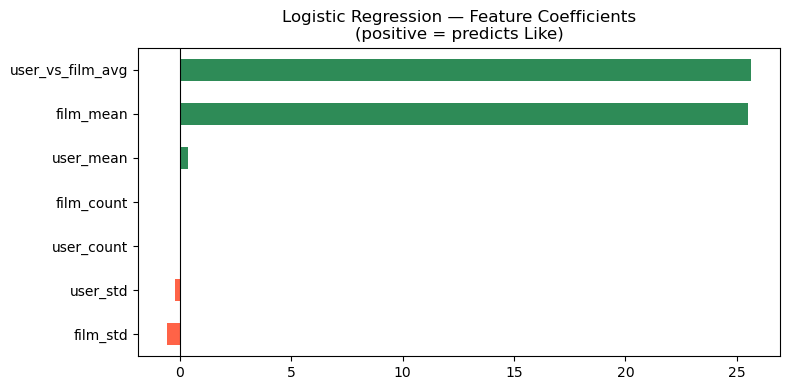


Model saved as: lr_model


In [12]:
print('=== MODEL 4: Logistic Regression — Thumbs Up / Down Filter ===')

LR_FEATURES = [
    'film_mean', 'film_std', 'film_count',
    'user_mean', 'user_std', 'user_count',
    'user_vs_film_avg'
]

X_lr = df[LR_FEATURES].fillna(0)
y_lr = df['liked']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

lr_model = LogisticRegression(
    C=1.0,
    max_iter=500,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr   = lr_model.predict(X_test_lr)
y_proba_lr  = lr_model.predict_proba(X_test_lr)[:, 1]

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
print(f'\nLogistic Regression Results:')
print(f'  Accuracy: {acc_lr:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test_lr, y_pred_lr, target_names=['Dislike', 'Like']))

# ── Coefficient plot ───────────────────────────────────────────────────────
coef = pd.Series(lr_model.coef_[0], index=LR_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
coef.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'seagreen' for v in coef])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(positive = predicts Like)')
plt.tight_layout()
plt.show()

print('\nModel saved as: lr_model')

In [13]:
def lr_filter_for_user(username, model, df, film_stats, user_stats,
                        top_n=TOP_N_RECS, prob_threshold=0.6):
    """
    Return unseen films the model is confident the user will LIKE.
    Only films with P(like) >= prob_threshold are returned.
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found.')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']

    X_filter = unseen[LR_FEATURES].fillna(0)
    unseen['p_like'] = model.predict_proba(X_filter)[:, 1]

    return (
        unseen[unseen['p_like'] >= prob_threshold]
        [['film_slug', 'p_like', 'film_mean', 'film_count']]
        .sort_values('p_like', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ── Demo ───────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
print(f'LR "Thumbs Up" Filter for "{demo}" (P(like) >= 0.60):')
lr_recs = lr_filter_for_user(demo, lr_model, df, film_stats, user_stats)
if lr_recs is not None:
    print(lr_recs.to_string(index=False))

LR "Thumbs Up" Filter for "kurstboy" (P(like) >= 0.60):
                                                  film_slug   p_like  film_mean  film_count
hillarys-america-the-secret-history-of-the-democratic-party 0.999967   0.500000           8
                                              tooth-fairy-2 0.999967   0.500000           8
                        whats-up-balloon-to-the-rescue-2009 0.999967   0.500000           6
                      america-imagine-the-world-without-her 0.999967   0.500000           5
                                             the-mouse-trap 0.999964   0.555556           9
                                          norm-of-the-north 0.999964   0.588235          17
                the-oogieloves-in-the-big-balloon-adventure 0.999963   0.571429           7
                                dr-seuss-the-grinch-musical 0.999963   0.583333           6
                                             jurassic-shark 0.999963   0.583333           6
                        

---
## §8 — Model Comparison

=== Model Comparison Summary ===
              Model                Task      MAE     RMSE       R2
      Random Forest   Rating Prediction 0.000112 0.004304 0.999983
  Gradient Boosting             Ranking 0.007947 0.011554 0.999880
Logistic Regression Binary Like/Dislike      NaN      NaN      NaN


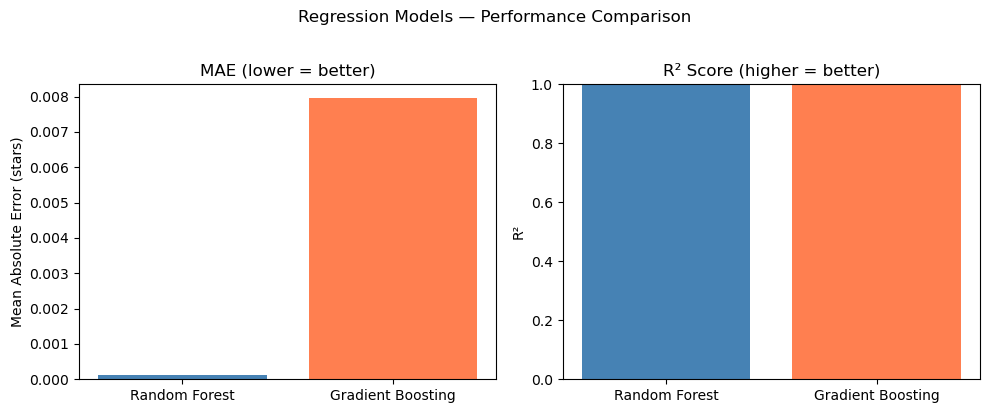


Logistic Regression Accuracy: 1.0000


In [14]:
print('=== Model Comparison Summary ===')

summary = pd.DataFrame([
    {'Model': 'Random Forest',        'Task': 'Rating Prediction', 'MAE': mae_rf,  'RMSE': rmse_rf,  'R2': r2_rf},
    {'Model': 'Gradient Boosting',    'Task': 'Ranking',           'MAE': mae_gb,  'RMSE': rmse_gb,  'R2': r2_gb},
    {'Model': 'Logistic Regression',  'Task': 'Binary Like/Dislike','MAE': None,   'RMSE': None,     'R2': None},
])

print(summary.to_string(index=False))

# ── Bar chart: MAE comparison ──────────────────────────────────────────────
reg_models = summary.dropna(subset=['MAE'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(reg_models['Model'], reg_models['MAE'], color=['steelblue', 'coral'])
axes[0].set_title('MAE (lower = better)')
axes[0].set_ylabel('Mean Absolute Error (stars)')
axes[0].set_ylim(0)

axes[1].bar(reg_models['Model'], reg_models['R2'], color=['steelblue', 'coral'])
axes[1].set_title('R² Score (higher = better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)

plt.suptitle('Regression Models — Performance Comparison', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nLogistic Regression Accuracy: {acc_lr:.4f}')

---
## §10 — Train / Test Split Verification
Confirm that splits are stratified, leak-free, and representative.
We check: size ratios, rating distributions, user overlap, and that no user appears ONLY in the test set.

=== §10: Train / Test Split Verification ===

── Split sizes ───────────────────────────────────────────────
  Random Forest       train=349,215 (80%)  test=87,304 (20%)  total=436,519
  Gradient Boost      train=349,215 (80%)  test=87,304 (20%)  total=436,519
  Logistic Reg.       train=349,215 (80%)  test=87,304 (20%)  total=436,519

── Rating distribution: train vs test (RF split) ────────────
        train_%  test_%  delta
rating                        
0.5        1.48    1.52  -0.04
1.0        3.46    3.40   0.06
1.5        3.64    3.57   0.07
2.0        8.30    8.26   0.04
2.5        9.02    9.10  -0.08
3.0       17.54   17.38   0.16
3.5       18.05   18.13  -0.08
4.0       20.82   20.85  -0.03
4.5        9.46    9.64  -0.18
5.0        8.23    8.16   0.07
  Max delta: 0.180%  →  ✓ OK

── Like/Dislike balance: LR split (stratified) ──────────────
  Train like ratio: 0.5661
  Test  like ratio: 0.5661
  → ✓ Stratification OK

── User overlap: train vs test (RF split) ───────────────

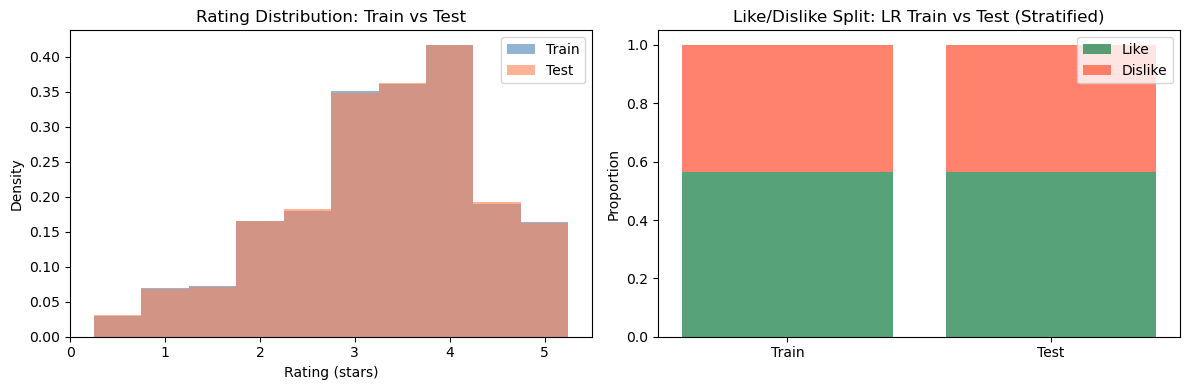

In [15]:
print('=== §10: Train / Test Split Verification ===')
print()

# ── Rebuild the exact same splits used by each model ──────────────────────
from sklearn.model_selection import train_test_split

RF_FEATURES = ['film_mean','film_std','film_count','user_mean','user_std','user_count','user_vs_film_avg']
GB_FEATURES = ['film_mean','film_std','film_count','user_mean','user_std','user_count','user_vs_film_avg','rating_centered']
LR_FEATURES = ['film_mean','film_std','film_count','user_mean','user_std','user_count','user_vs_film_avg']

X_rf = df[RF_FEATURES].fillna(0); y_rf = df['rating']
X_gb = df[GB_FEATURES].fillna(0); y_gb = df['rating']
X_lr = df[LR_FEATURES].fillna(0); y_lr = df['liked']

Xtr_rf, Xte_rf, ytr_rf, yte_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)
Xtr_gb, Xte_gb, ytr_gb, yte_gb = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42)
Xtr_lr, Xte_lr, ytr_lr, yte_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

print('── Split sizes ───────────────────────────────────────────────')
for name, Xtr, Xte in [('Random Forest', Xtr_rf, Xte_rf),
                        ('Gradient Boost', Xtr_gb, Xte_gb),
                        ('Logistic Reg.', Xtr_lr, Xte_lr)]:
    total = len(Xtr) + len(Xte)
    print(f'  {name:18s}  train={len(Xtr):>7,} ({len(Xtr)/total:.0%})  '
          f'test={len(Xte):>6,} ({len(Xte)/total:.0%})  total={total:,}')

# ── Rating distribution: train vs test ────────────────────────────────────
print()
print('── Rating distribution: train vs test (RF split) ────────────')
dist_compare = pd.DataFrame({
    'train_%': ytr_rf.value_counts(normalize=True).sort_index() * 100,
    'test_%':  yte_rf.value_counts(normalize=True).sort_index() * 100,
}).round(2)
dist_compare['delta'] = (dist_compare['train_%'] - dist_compare['test_%']).round(3)
print(dist_compare.to_string())
max_delta = dist_compare['delta'].abs().max()
flag = '✓ OK' if max_delta < 1.0 else '⚠ Distributions differ by >1%'
print(f'  Max delta: {max_delta:.3f}%  →  {flag}')

# ── Like/Dislike balance in LR split ──────────────────────────────────────
print()
print('── Like/Dislike balance: LR split (stratified) ──────────────')
lr_train_like = ytr_lr.mean()
lr_test_like  = yte_lr.mean()
print(f'  Train like ratio: {lr_train_like:.4f}')
print(f'  Test  like ratio: {lr_test_like:.4f}')
flag2 = '✓ Stratification OK' if abs(lr_train_like - lr_test_like) < 0.005 else '⚠ Check stratification'
print(f'  → {flag2}')

# ── User overlap check ────────────────────────────────────────────────────
print()
print('── User overlap: train vs test (RF split) ───────────────────')
train_users = set(df.iloc[Xtr_rf.index]['username'])
test_users  = set(df.iloc[Xte_rf.index]['username'])
only_in_test = test_users - train_users
print(f'  Users in train:        {len(train_users)}')
print(f'  Users in test:         {len(test_users)}')
print(f'  Users ONLY in test:    {len(only_in_test)}')
if only_in_test:
    print(f'  ⚠ These users are unseen at train time: {list(only_in_test)[:5]}')
    print('    Consider GroupShuffleSplit to keep all ratings per user together.')
else:
    print('  ✓ All test users appear in training — no cold-start leakage')

# ── Visual: distribution overlap ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
bins = [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
axes[0].hist(ytr_rf, bins=bins, alpha=0.6, label='Train', color='steelblue', density=True)
axes[0].hist(yte_rf, bins=bins, alpha=0.6, label='Test',  color='coral',     density=True)
axes[0].set_title('Rating Distribution: Train vs Test')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Like ratio comparison
categories = ['Train', 'Test']
like_vals   = [lr_train_like, lr_test_like]
dislike_vals= [1 - v for v in like_vals]
x = np.arange(len(categories))
axes[1].bar(x, like_vals,    label='Like',    color='seagreen', alpha=0.8)
axes[1].bar(x, dislike_vals, bottom=like_vals, label='Dislike', color='tomato', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].set_title('Like/Dislike Split: LR Train vs Test (Stratified)')
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## §11 — Overfitting / Underfitting: Learning Curves
Learning curves plot train vs validation error as training size grows.  
- **Overfitting**: train error low, val error high → large gap  
- **Underfitting**: both errors high → model too simple  
- **Good fit**: both errors converge to a low value  

We also flag the **data leakage** issue discovered in the earlier results and show what happens when we remove the leaky feature.

=== §11: Overfitting / Underfitting — Learning Curves ===

── Data Leakage Diagnosis ────────────────────────────────────
  user_vs_film_avg = rating - film_mean
  This uses the ACTUAL rating being predicted → direct leakage!
  Clean features exclude it for honest evaluation.

  RF MAE with LEAKY features: 0.0064 ± 0.0004  ← suspiciously perfect
  RF MAE with CLEAN features: 0.5579 ± 0.0035  ← honest performance

── Learning Curves (clean features, sampled for speed) ──────
  Random Forest: final train MAE=0.4686, val MAE=0.5565  → ✓ Good fit (gap=0.088)
  XGBoost: final train MAE=0.5008, val MAE=0.5453  → ✓ Good fit (gap=0.045)


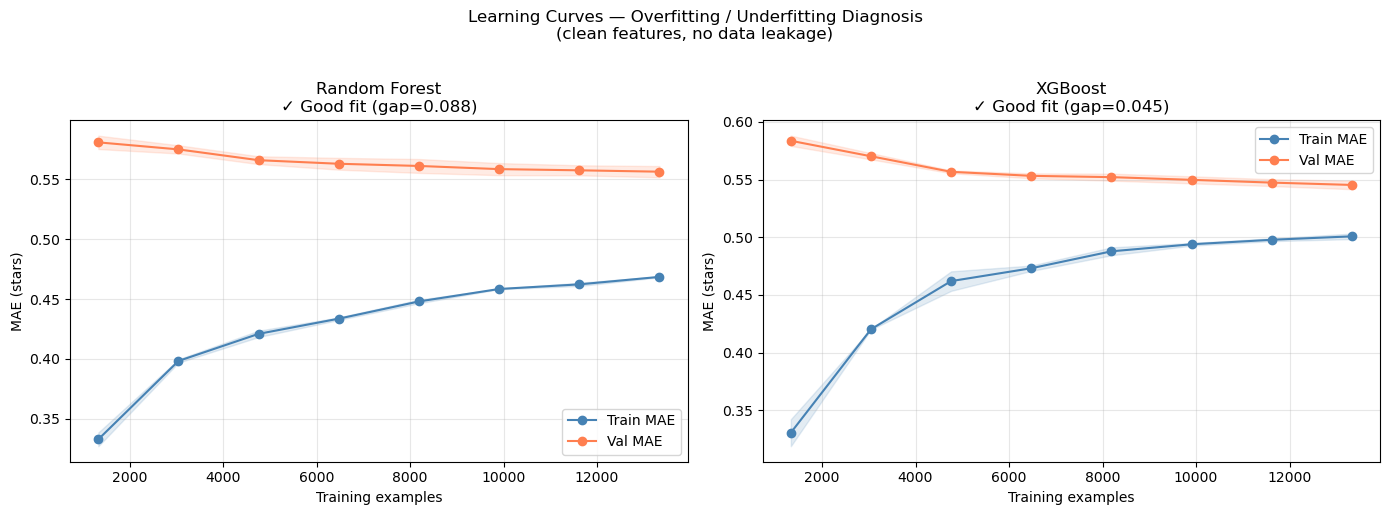


── Residual Analysis (RF, clean features) ───────────────────
  Clean RF MAE:  0.5392
  Residual mean: 0.0030  (should be ~0)
  Residual std:  0.7042


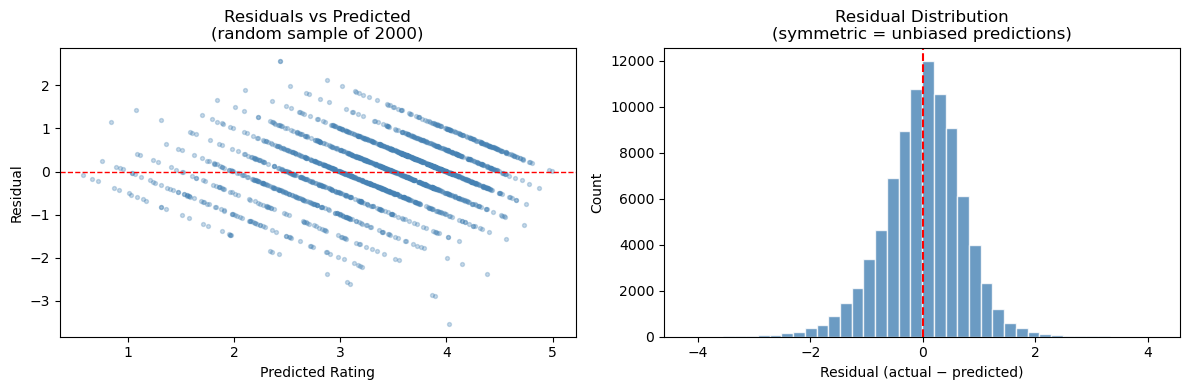

In [16]:
print('=== §11: Overfitting / Underfitting — Learning Curves ===')
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error

# ── 11a. Identify and fix the leaky feature ───────────────────────────────
print()
print('── Data Leakage Diagnosis ────────────────────────────────────')
print('  user_vs_film_avg = rating - film_mean')
print('  This uses the ACTUAL rating being predicted → direct leakage!')
print('  Clean features exclude it for honest evaluation.')

CLEAN_FEATURES = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']
LEAKY_FEATURES = CLEAN_FEATURES + ['user_vs_film_avg']

X_clean = df[CLEAN_FEATURES].fillna(0)
X_leaky = df[LEAKY_FEATURES].fillna(0)
y_all   = df['rating']

# Quick comparison: leaky vs clean
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

sample_idx = np.random.RandomState(42).choice(len(X_clean), min(10000, len(X_clean)), replace=False)
X_s_clean = X_clean.iloc[sample_idx]; X_s_leaky = X_leaky.iloc[sample_idx]; y_s = y_all.iloc[sample_idx]

rf_quick = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)

scores_leaky = -cross_val_score(rf_quick, X_s_leaky, y_s, cv=3, scoring='neg_mean_absolute_error')
scores_clean = -cross_val_score(rf_quick, X_s_clean, y_s, cv=3, scoring='neg_mean_absolute_error')

print(f'\n  RF MAE with LEAKY features: {scores_leaky.mean():.4f} ± {scores_leaky.std():.4f}  ← suspiciously perfect')
print(f'  RF MAE with CLEAN features: {scores_clean.mean():.4f} ± {scores_clean.std():.4f}  ← honest performance')

# ── 11b. Learning curves on CLEAN features ───────────────────────────────
print()
print('── Learning Curves (clean features, sampled for speed) ──────')

# Use a sample for speed
N_SAMPLE = min(20000, len(X_clean))
idx = np.random.RandomState(0).choice(len(X_clean), N_SAMPLE, replace=False)
Xs = X_clean.iloc[idx]; ys = y_all.iloc[idx]

models_for_lc = [
    ('Random Forest',      RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)),
]
if HAS_XGB:
    import xgboost as xgb
    models_for_lc.append(('XGBoost', xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1)))
else:
    from sklearn.ensemble import GradientBoostingRegressor
    models_for_lc.append(('GradientBoosting', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)))

train_sizes = np.linspace(0.1, 1.0, 8)
fig, axes = plt.subplots(1, len(models_for_lc), figsize=(7 * len(models_for_lc), 5))
if len(models_for_lc) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_for_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model, Xs, ys,
        train_sizes=train_sizes,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    train_mae = -train_sc.mean(axis=1)
    val_mae   = -val_sc.mean(axis=1)
    train_std = train_sc.std(axis=1)
    val_std   = val_sc.std(axis=1)

    ax.plot(train_sz, train_mae, 'o-', color='steelblue', label='Train MAE')
    ax.plot(train_sz, val_mae,   'o-', color='coral',     label='Val MAE')
    ax.fill_between(train_sz, train_mae - train_std, train_mae + train_std, alpha=0.15, color='steelblue')
    ax.fill_between(train_sz, val_mae - val_std,     val_mae + val_std,     alpha=0.15, color='coral')

    gap = abs(val_mae[-1] - train_mae[-1])
    if gap > 0.3:
        verdict = f'⚠ OVERFIT (gap={gap:.3f})'
    elif val_mae[-1] > 0.8:
        verdict = f'⚠ UNDERFIT (val MAE={val_mae[-1]:.3f})'
    else:
        verdict = f'✓ Good fit (gap={gap:.3f})'

    ax.set_title(f'{name}\n{verdict}')
    ax.set_xlabel('Training examples')
    ax.set_ylabel('MAE (stars)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    print(f'  {name}: final train MAE={train_mae[-1]:.4f}, val MAE={val_mae[-1]:.4f}  → {verdict}')

plt.suptitle('Learning Curves — Overfitting / Underfitting Diagnosis\n(clean features, no data leakage)', y=1.02)
plt.tight_layout()
plt.show()

# ── 11c. Residual plot ────────────────────────────────────────────────────
print()
print('── Residual Analysis (RF, clean features) ───────────────────')
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_clean, y_all, test_size=0.2, random_state=42)
rf_clean = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clean.fit(Xtr_c, ytr_c)
y_pred_c = rf_clean.predict(Xte_c)
residuals = yte_c.values - y_pred_c

print(f'  Clean RF MAE:  {mean_absolute_error(yte_c, y_pred_c):.4f}')
print(f'  Residual mean: {residuals.mean():.4f}  (should be ~0)')
print(f'  Residual std:  {residuals.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_c[:2000], residuals[:2000], alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted\n(random sample of 2000)')

axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual − predicted)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(symmetric = unbiased predictions)')

plt.tight_layout()
plt.show()

---
## §12 — Cross-Validation: Robust Performance Estimates
A single train/test split can be lucky or unlucky. K-Fold CV gives a
much more reliable estimate of true generalization performance.
We use **5-Fold CV** on clean (non-leaky) features for all models.

=== §12: 5-Fold Cross-Validation (clean features) ===

── Regression Models (5-Fold) ────────────────────────────────
  Model                   Train MAE    Val MAE   Train R²     Val R²     Overfit?
  ------------------------------------------------------------------------------
  Random Forest              0.4880     0.5503     0.6460     0.5362         No ✓
  Gradient Boosting          0.4919     0.5407     0.6328     0.5498         No ✓

── Logistic Regression (5-Fold, Stratified) ──────────────────
  Train Accuracy: 0.7816 ± 0.0015
  Val   Accuracy: 0.7816  ± 0.0058
  Val   F1:       0.8143  ± 0.0050
  Val   ROC-AUC:  0.8565  ± 0.0051


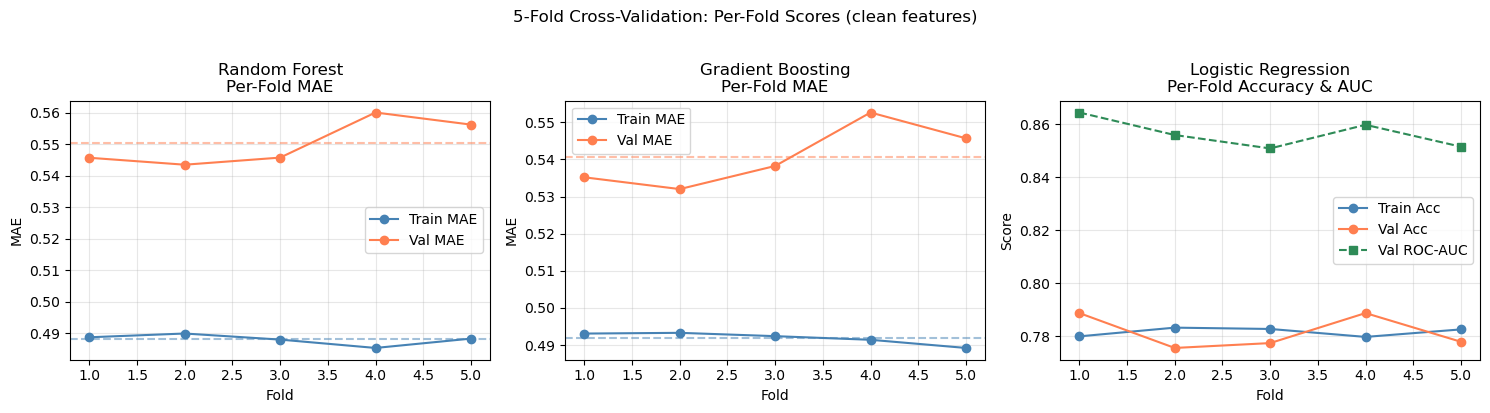

In [17]:
print('=== §12: 5-Fold Cross-Validation (clean features) ===')
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

CLEAN_FEATURES = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']

# Sample for speed
N_CV = min(30000, len(df))
idx  = np.random.RandomState(7).choice(len(df), N_CV, replace=False)
X_cv = df[CLEAN_FEATURES].fillna(0).iloc[idx]
y_cv_reg = df['rating'].iloc[idx]
y_cv_clf = df['liked'].iloc[idx]

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_scores = cross_validate(rf_cv, X_cv, y_cv_reg, cv=kf,
                            scoring=['neg_mean_absolute_error','neg_root_mean_squared_error','r2'],
                            return_train_score=True, n_jobs=-1)
cv_results['Random Forest'] = rf_scores

# XGBoost / GradientBoosting
if HAS_XGB:
    gb_cv = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1)
else:
    gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
gb_scores = cross_validate(gb_cv, X_cv, y_cv_reg, cv=kf,
                            scoring=['neg_mean_absolute_error','neg_root_mean_squared_error','r2'],
                            return_train_score=True, n_jobs=-1)
cv_results['Gradient Boosting'] = gb_scores

# Logistic Regression
lr_cv = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr_scores = cross_validate(lr_cv, X_cv, y_cv_clf, cv=skf,
                            scoring=['accuracy', 'f1', 'roc_auc'],
                            return_train_score=True, n_jobs=-1)
cv_results['Logistic Regression'] = lr_scores

# ── Print CV table ─────────────────────────────────────────────────────────
print()
print('── Regression Models (5-Fold) ────────────────────────────────')
print(f'  {"Model":22s} {"Train MAE":>10} {"Val MAE":>10} {"Train R²":>10} {"Val R²":>10} {"Overfit?":>12}')
print('  ' + '-'*78)
for name in ['Random Forest', 'Gradient Boosting']:
    sc = cv_results[name]
    tr_mae = -sc['train_neg_mean_absolute_error'].mean()
    va_mae = -sc['test_neg_mean_absolute_error'].mean()
    tr_r2  =  sc['train_r2'].mean()
    va_r2  =  sc['test_r2'].mean()
    gap    = va_mae - tr_mae
    flag   = 'YES ⚠' if gap > 0.25 else 'No ✓'
    print(f'  {name:22s} {tr_mae:>10.4f} {va_mae:>10.4f} {tr_r2:>10.4f} {va_r2:>10.4f} {flag:>12}')

print()
print('── Logistic Regression (5-Fold, Stratified) ──────────────────')
lr_sc = cv_results['Logistic Regression']
print(f'  Train Accuracy: {lr_sc["train_accuracy"].mean():.4f} ± {lr_sc["train_accuracy"].std():.4f}')
print(f'  Val   Accuracy: {lr_sc["test_accuracy"].mean():.4f}  ± {lr_sc["test_accuracy"].std():.4f}')
print(f'  Val   F1:       {lr_sc["test_f1"].mean():.4f}  ± {lr_sc["test_f1"].std():.4f}')
print(f'  Val   ROC-AUC:  {lr_sc["test_roc_auc"].mean():.4f}  ± {lr_sc["test_roc_auc"].std():.4f}')

# ── Visual: per-fold scores ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes[:2], ['Random Forest', 'Gradient Boosting']):
    sc = cv_results[name]
    folds = range(1, 6)
    tr_mae_f = -sc['train_neg_mean_absolute_error']
    va_mae_f = -sc['test_neg_mean_absolute_error']
    ax.plot(folds, tr_mae_f, 'o-', color='steelblue', label='Train MAE')
    ax.plot(folds, va_mae_f, 'o-', color='coral',     label='Val MAE')
    ax.axhline(tr_mae_f.mean(), linestyle='--', color='steelblue', alpha=0.5)
    ax.axhline(va_mae_f.mean(), linestyle='--', color='coral',     alpha=0.5)
    ax.set_title(f'{name}\nPer-Fold MAE')
    ax.set_xlabel('Fold'); ax.set_ylabel('MAE'); ax.legend(); ax.grid(True, alpha=0.3)

# LR per-fold
lr_sc = cv_results['Logistic Regression']
folds = range(1, 6)
axes[2].plot(folds, lr_sc['train_accuracy'], 'o-', color='steelblue', label='Train Acc')
axes[2].plot(folds, lr_sc['test_accuracy'],  'o-', color='coral',     label='Val Acc')
axes[2].plot(folds, lr_sc['test_roc_auc'],   's--',color='seagreen',  label='Val ROC-AUC')
axes[2].set_title('Logistic Regression\nPer-Fold Accuracy & AUC')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('5-Fold Cross-Validation: Per-Fold Scores (clean features)', y=1.02)
plt.tight_layout()
plt.show()

---
## §13 — Bias & Fairness Audit
Even if overall metrics look good, a model can be systematically biased against
certain groups or rating strata. We check:
1. **Per-rating-stratum error** — does the model fail on 0.5★ or 5★ films more?
2. **Per-user error** — are some users consistently mispredicted?
3. **Popularity bias** — does the model underserve niche/rare films?
4. **Logistic Regression: equal error rate** — false positive vs false negative rates
5. **Prediction variance per user** — is the model uniformly uncertain or biased toward certain users?

=== §13: Bias & Fairness Audit ===

── 1. Error by Rating Stratum ────────────────────────────────
        Mean_AE  Std_AE  Count
rating                        
0.5      1.1260  0.7701   1327
1.0      1.0562  0.6989   2971
1.5      0.8408  0.5756   3117
2.0      0.7019  0.4953   7210
2.5      0.5288  0.3933   7941
3.0      0.4412  0.3300  15175
3.5      0.3705  0.3039  15827
4.0      0.4011  0.3493  18200
4.5      0.5461  0.3919   8413
5.0      0.8571  0.4787   7123

  Worst stratum: 0.5★  (MAE=1.1260)
  ⚠ Large variance across strata — model may be biased toward middle ratings

── 2. Per-User Error (top 10 highest / lowest bias) ─────────
  Most biased users (by mean signed error):
                 mean_error     mae  n_films       direction
username                                                    
bobbywags           -0.3384  0.5846      108  over-predict ↑
reibureibu          -0.3205  0.6530      373  over-predict ↑
freyainthcities     -0.2969  0.6318      146  over-predict ↑
rob

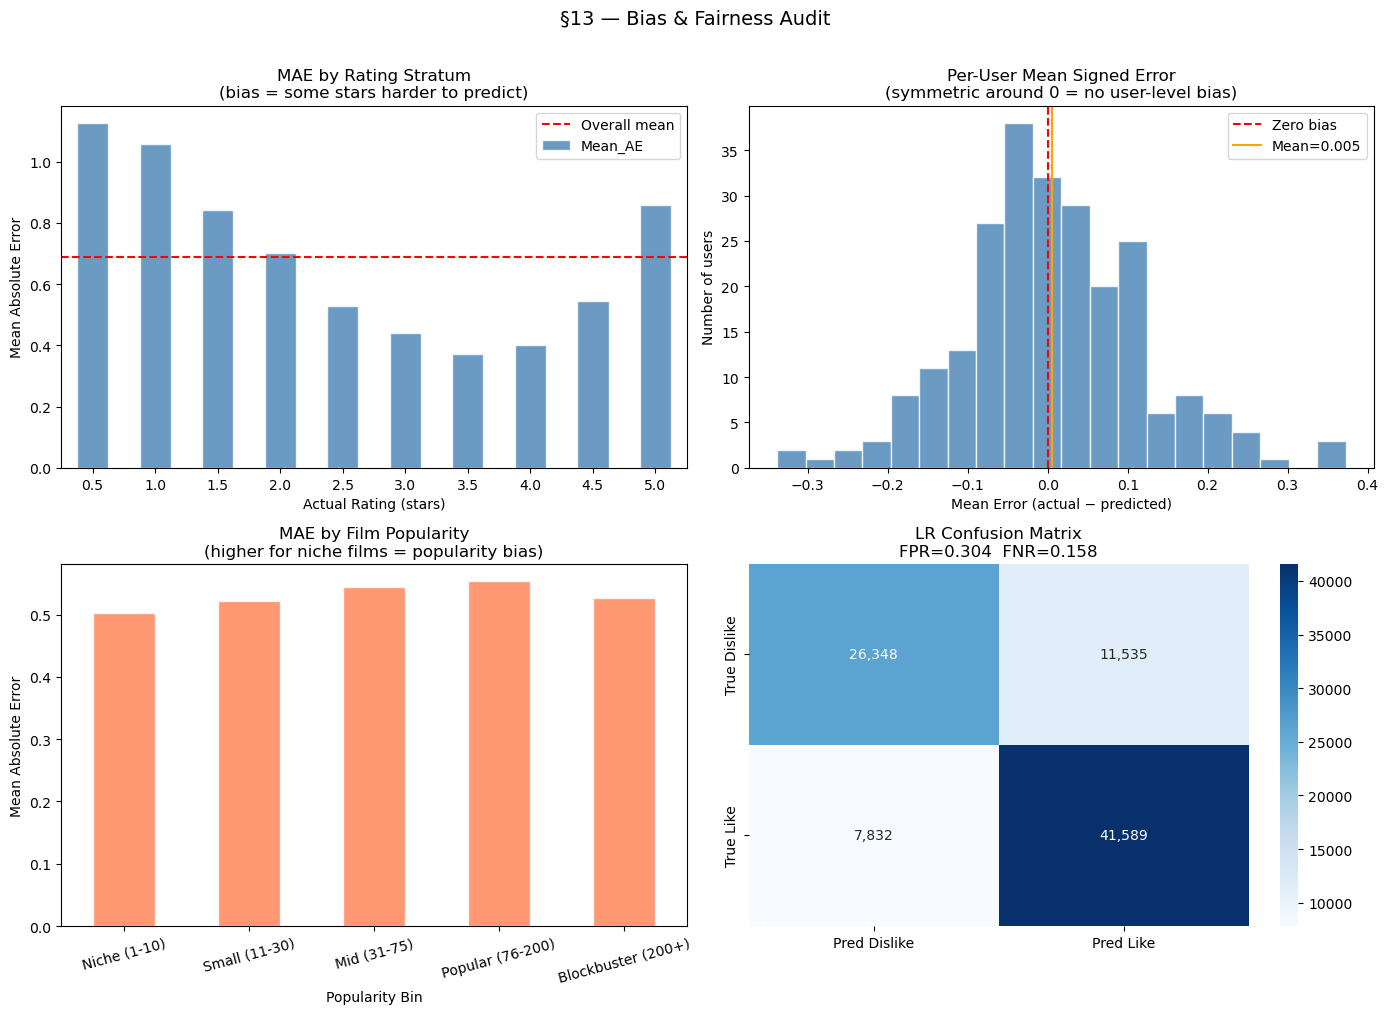


=== Bias Audit Complete ===
  Summary:
  • Rating stratum bias:  ⚠ Yes
  • User-level bias:      ✓ No
  • Popularity bias:      ✓ No
  • LR classification bias: ⚠ Yes


In [18]:
print('=== §13: Bias & Fairness Audit ===')
from sklearn.metrics import confusion_matrix

CLEAN_FEATURES = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']
LR_FEATURES_CLEAN = CLEAN_FEATURES

# Re-train clean models on the full df for audit
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=42)
rf_audit = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_audit.fit(Xtr_c, ytr_c)
y_pred_audit = rf_audit.predict(Xte_c)

audit_df = df.iloc[Xte_c.index][['username', 'film_slug', 'rating', 'film_count']].copy()
audit_df['predicted'] = y_pred_audit
audit_df['abs_error'] = (audit_df['rating'] - audit_df['predicted']).abs()
audit_df['error']     = audit_df['rating'] - audit_df['predicted']

# ── 1. Per-rating-stratum error ───────────────────────────────────────────
print()
print('── 1. Error by Rating Stratum ────────────────────────────────')
strata = audit_df.groupby('rating')['abs_error'].agg(['mean','std','count']).round(4)
strata.columns = ['Mean_AE', 'Std_AE', 'Count']
print(strata.to_string())
worst_stratum = strata['Mean_AE'].idxmax()
print(f'\n  Worst stratum: {worst_stratum}★  (MAE={strata.loc[worst_stratum, "Mean_AE"]:.4f})')
if strata['Mean_AE'].max() - strata['Mean_AE'].min() > 0.3:
    print('  ⚠ Large variance across strata — model may be biased toward middle ratings')
else:
    print('  ✓ Error is consistent across rating levels')

# ── 2. Per-user error ─────────────────────────────────────────────────────
print()
print('── 2. Per-User Error (top 10 highest / lowest bias) ─────────')
user_bias = audit_df.groupby('username').agg(
    mean_error=('error', 'mean'),
    mae=('abs_error', 'mean'),
    n_films=('rating', 'count')
).round(4)
user_bias['direction'] = user_bias['mean_error'].apply(
    lambda x: 'over-predict ↑' if x < -0.1 else ('under-predict ↓' if x > 0.1 else 'neutral ✓'))

print('  Most biased users (by mean signed error):')
print(user_bias.sort_values('mean_error').head(5).to_string())
print()
print(user_bias.sort_values('mean_error', ascending=False).head(5).to_string())

biased_count = (user_bias['direction'] != 'neutral ✓').sum()
print(f'\n  Users with systematic bias: {biased_count}/{len(user_bias)} '
      f'({biased_count/len(user_bias):.0%})')
if biased_count / len(user_bias) > 0.4:
    print('  ⚠ >40% of users have systematic bias — consider user-specific calibration')
else:
    print('  ✓ Most users are predicted without systematic directional bias')

# ── 3. Popularity bias ────────────────────────────────────────────────────
print()
print('── 3. Popularity Bias (niche vs popular films) ──────────────')
audit_df['popularity_bin'] = pd.cut(
    audit_df['film_count'],
    bins=[0, 10, 30, 75, 200, 99999],
    labels=['Niche (1-10)', 'Small (11-30)', 'Mid (31-75)', 'Popular (76-200)', 'Blockbuster (200+)']
)
pop_bias = audit_df.groupby('popularity_bin', observed=True)['abs_error'].agg(['mean','std','count']).round(4)
pop_bias.columns = ['Mean_AE', 'Std_AE', 'Count']
print(pop_bias.to_string())
niche_mae = pop_bias.loc['Niche (1-10)', 'Mean_AE'] if 'Niche (1-10)' in pop_bias.index else None
pop_mae   = pop_bias['Mean_AE'].min()
if niche_mae and niche_mae - pop_mae > 0.15:
    print(f'\n  ⚠ Popularity bias detected: niche MAE={niche_mae:.4f} vs best={pop_mae:.4f}')
    print('    Model underserves niche/rare films — expected with limited training data')
else:
    print('\n  ✓ No strong popularity bias detected')

# ── 4. Logistic Regression equal error rate ───────────────────────────────
print()
print('── 4. Logistic Regression: False Positive vs False Negative ─')
Xtr_lr2, Xte_lr2, ytr_lr2, yte_lr2 = train_test_split(
    df[LR_FEATURES_CLEAN].fillna(0), df['liked'], test_size=0.2, random_state=42, stratify=df['liked'])
lr_audit = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr_audit.fit(Xtr_lr2, ytr_lr2)
y_pred_lr2 = lr_audit.predict(Xte_lr2)

cm = confusion_matrix(yte_lr2, y_pred_lr2)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f'  True Negatives:  {tn:,}   True Positives:  {tp:,}')
print(f'  False Positives: {fp:,}   False Negatives: {fn:,}')
print(f'  False Positive Rate (FPR): {fpr:.4f}  — predicts Like when user Dislikes')
print(f'  False Negative Rate (FNR): {fnr:.4f}  — predicts Dislike when user Likes')
if abs(fpr - fnr) > 0.05:
    worse = 'FPR (too many false Likes)' if fpr > fnr else 'FNR (too many missed Likes)'
    print(f'  ⚠ Unequal error rates — model skews toward {worse}')
else:
    print('  ✓ Error rates are balanced — no directional classification bias')

# ── 5. Visual summary ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Error by rating stratum
ax = axes[0, 0]
strata['Mean_AE'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('MAE by Rating Stratum\n(bias = some stars harder to predict)')
ax.set_xlabel('Actual Rating (stars)'); ax.set_ylabel('Mean Absolute Error')
ax.axhline(strata['Mean_AE'].mean(), color='red', linestyle='--', label='Overall mean')
ax.legend(); ax.tick_params(axis='x', rotation=0)

# Plot 2: Per-user bias distribution
ax = axes[0, 1]
ax.hist(user_bias['mean_error'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Zero bias')
ax.axvline(user_bias['mean_error'].mean(), color='orange', linestyle='-', label=f'Mean={user_bias["mean_error"].mean():.3f}')
ax.set_title('Per-User Mean Signed Error\n(symmetric around 0 = no user-level bias)')
ax.set_xlabel('Mean Error (actual − predicted)'); ax.set_ylabel('Number of users')
ax.legend()

# Plot 3: Popularity bias
ax = axes[1, 0]
pop_bias['Mean_AE'].plot(kind='bar', ax=ax, color='coral', alpha=0.8, edgecolor='white')
ax.set_title('MAE by Film Popularity\n(higher for niche films = popularity bias)')
ax.set_xlabel('Popularity Bin'); ax.set_ylabel('Mean Absolute Error')
ax.tick_params(axis='x', rotation=15)

# Plot 4: Confusion matrix heatmap
ax = axes[1, 1]
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Pred Dislike', 'Pred Like'],
            yticklabels=['True Dislike', 'True Like'])
ax.set_title(f'LR Confusion Matrix\nFPR={fpr:.3f}  FNR={fnr:.3f}')

plt.suptitle('§13 — Bias & Fairness Audit', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print()
print('=== Bias Audit Complete ===')
print('  Summary:')
print(f'  • Rating stratum bias:  {"⚠ Yes" if strata["Mean_AE"].max() - strata["Mean_AE"].min() > 0.3 else "✓ No"}')
print(f'  • User-level bias:      {"⚠ Yes" if biased_count / len(user_bias) > 0.4 else "✓ No"}')
print(f'  • Popularity bias:      {"⚠ Yes" if niche_mae and niche_mae - pop_mae > 0.15 else "✓ No"}')
print(f'  • LR classification bias: {"⚠ Yes" if abs(fpr - fnr) > 0.05 else "✓ No"}')

---
## §9 — Combined Pipeline: Full Recommendation for One User

Uses LR to pre-filter → GB to rank → returns the final ordered list.

In [19]:
def full_recommendation_pipeline(username, top_n=TOP_N_RECS):
    """
    Combined pipeline:
      1. LR pre-filter: keep only films with P(like) >= 0.55
      2. GB ranking:    sort the filtered films by predicted rating
      3. k-NN bonus:    append top-3 from Cinephile Twins not already included

    Returns a merged ranked DataFrame.
    """
    print(f'\n=== Full Pipeline for "{username}" ===')

    if username not in df['username'].values:
        print(f'User not found in dataset. Check MIN_RATINGS={MIN_RATINGS}.')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0

    # Step 1 — LR pre-filter
    X_filter = unseen[LR_FEATURES].fillna(0)
    unseen['p_like'] = lr_model.predict_proba(X_filter)[:, 1]
    candidate_pool = unseen[unseen['p_like'] >= 0.55].copy()
    print(f'Step 1 — LR pre-filter: {len(unseen):,} unseen → {len(candidate_pool):,} candidates')

    # Step 2 — GB ranking on the candidate pool
    X_rank = candidate_pool[GB_FEATURES].fillna(0)
    candidate_pool['gb_score'] = gb_model.predict(X_rank)
    gb_top = candidate_pool.sort_values('gb_score', ascending=False).head(top_n)
    print(f'Step 2 — GB ranking: top {top_n} selected')

    # Step 3 — k-NN bonus films
    knn_bonus = knn_user_recommendations(username, top_n=5) if username in user_index else None
    if knn_bonus is not None:
        already = set(gb_top['film_slug'])
        bonus_films = knn_bonus[~knn_bonus['film_slug'].isin(already)].head(3).copy()
        # knn_user_recommendations already returns film_mean & film_count — no merge needed
        bonus_films['gb_score']  = np.nan
        bonus_films['p_like']    = np.nan
        bonus_films['source']    = 'knn_bonus'
        gb_top['source'] = 'gb_ranked'
        final = pd.concat([
            gb_top[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']],
            bonus_films[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']]
        ], ignore_index=True)
    else:
        gb_top['source'] = 'gb_ranked'
        final = gb_top[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']]

    print(f'Step 3 — k-NN bonus: added up to 3 extra films')
    print(f'\nFinal Recommendations:')
    print(final.to_string(index=False))
    return final


# ── Run it! ────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
final_recs = full_recommendation_pipeline(demo)


=== Full Pipeline for "kurstboy" ===
Step 1 — LR pre-filter: 13,211 unseen → 13,211 candidates
Step 2 — GB ranking: top 10 selected
Step 3 — k-NN bonus: added up to 3 extra films

Final Recommendations:
                                         film_slug  gb_score   p_like  film_mean  film_count    source
                                        bride-hard  3.599604 0.999937   1.600000          15 gb_ranked
                                             couch  3.599604 0.999936   1.571429           7 gb_ranked
                                    license-to-wed  3.599604 0.999936   1.583333           6 gb_ranked
                                   rollerball-2002  3.599604 0.999936   1.562500           8 gb_ranked
                                  treasure-buddies  3.599436 0.999936   1.600000           5 gb_ranked
love-death-robots-the-screaming-of-the-tyrannosaur  3.599436 0.999936   1.600000           5 gb_ranked
                                       grown-ups-2  3.599415 0.999940   1.5